# Tóm tắt kết quả WMGF (Weighted Median Guided Filter) và Detection


In [1]:
import os
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import yaml
import sys
sys.path.append('A:/HUST_on_GitHub/ProjectCV')

from ultralytics import YOLO
from src.restoration.wmgf_derain import WMGFDerainFilter, WMGFConfig
from src.metrics.full_reference import compute_ssim, compute_psnr
from src.metrics.no_reference import compute_brisque


a:\HUST_on_GitHub\ProjectCV\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Tải các cấu hình và mô hình YOLO

In [2]:
import dataclasses

def load_cfg(path):
    if not os.path.exists(path):
        return {}
    with open(path, 'r') as f:
        cfg = yaml.safe_load(f)
    if not cfg:
        return {}
    
    valid_keys = {field.name for field in dataclasses.fields(WMGFConfig)}
    return {k: v for k, v in cfg.items() if k in valid_keys}

configs = {
    'Default WMGF': WMGFConfig(**load_cfg('A:/HUST_on_GitHub/ProjectCV/configs/wmgf/derain_wmgf_default.yaml')),
    'Config1 (SSIM)': WMGFConfig(**load_cfg('A:/HUST_on_GitHub/ProjectCV/results/optuna/wmgf_config1_ssim/best_config.yaml')) if os.path.exists('A:/HUST_on_GitHub/ProjectCV/results/optuna/wmgf_config1_ssim/best_config.yaml') else None,
    'Config2 (BRISQUE)': WMGFConfig(**load_cfg('A:/HUST_on_GitHub/ProjectCV/results/optuna/wmgf_config2_brisque/best_config.yaml')) if os.path.exists('A:/HUST_on_GitHub/ProjectCV/results/optuna/wmgf_config2_brisque/best_config.yaml') else None,
    'Config3 (mAP50)': WMGFConfig(**load_cfg('A:/HUST_on_GitHub/ProjectCV/results/optuna/wmgf_config3_map50/best_config.yaml')) if os.path.exists('A:/HUST_on_GitHub/ProjectCV/results/optuna/wmgf_config3_map50/best_config.yaml') else None
}

filters = {k: WMGFDerainFilter(v) for k, v in configs.items() if v is not None}

yolo_model = YOLO('A:/HUST_on_GitHub/ProjectCV/yolo26n.pt')


In [3]:
# Draw Ground Truth BB
def draw_gt_boxes(img, label_path):
    img_copy = img.copy()
    if not os.path.exists(label_path):
        return img_copy
        
    CLASS_NAMES = {
        0: "person",
        1: "bicycle",
        2: "car",
        3: "motorcycle",
        4: "airplane",
        5: "bus",
        6: "train",
        7: "truck"
    }

    h, w = img_copy.shape[:2]
    with open(label_path, 'r') as f:
        lines = f.readlines()
        
    for line in lines:
        parts = line.strip().split()
        if len(parts) >= 5:
            cls_id = int(parts[0])
            cls_name = CLASS_NAMES.get(cls_id, str(cls_id))
            
            x_center = float(parts[1]) * w
            y_center = float(parts[2]) * h
            box_w = float(parts[3]) * w
            box_h = float(parts[4]) * h
            
            x1 = int(x_center - box_w / 2)
            y1 = int(y_center - box_h / 2)
            x2 = int(x_center + box_w / 2)
            y2 = int(y_center + box_h / 2)
            
            cv2.rectangle(img_copy, (x1, y1), (x2, y2), (0, 255, 0), 3)
            cv2.putText(img_copy, f"GT: {cls_name}", (x1, max(y1 - 5, 0)), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
            
    return img_copy

def show_images_yolo(imgs, titles, figsize=(30, 5)):
    fig, axes = plt.subplots(1, len(imgs), figsize=figsize)
    if len(imgs) == 1: axes = [axes]
    for ax, img, title in zip(axes, imgs, titles):
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(title, fontsize=12, pad=10)
        ax.axis('off')
    plt.tight_layout()
    plt.show()


## 2. Bảng kết quả Metrics (Final Evaluation)

In [4]:
eval_csv = 'A:/HUST_on_GitHub/ProjectCV/results/wmgf_evaluation.csv'
if os.path.exists(eval_csv):
    df = pd.read_csv(eval_csv)
    display(df)
else:
    print("Chưa có file kết quả")


,Config,Paired_SSIM,Paired_PSNR,DAWN_BRISQUE,DAWN_NIQE,DAWN_PIQE,DAWN_Entropy,DAWN_mAP50,DAWN_mAP50-95,DAWN_IoU,DAWN_Precision,DAWN_Recall
0,WMGF_Default,0.386938,12.574573,71.315266,9.020719,76.267744,7.139362,0.109493,0.065085,0.059231,0.406596,0.107864
1,WMGF_Config1,0.433382,14.602153,50.309890,7.559964,57.524958,7.233608,0.106482,0.064745,0.083879,0.391113,0.084565
2,WMGF_Config2,0.273349,11.733574,33.285555,5.217754,41.897805,7.394787,0.125331,0.077922,0.096692,0.384601,0.125023
3,WMGF_Config3,0.298075,12.503093,37.409251,6.326419,46.807268,7.360318,0.127152,0.078016,0.095773,0.372608,0.132849


## 3. Trực quan hóa kết quả (Rain100H)
So sánh Rainy vs Ground Truth vs Default WMGF vs Config 1, 2, 3


--- Visualization: norain-1.png ---


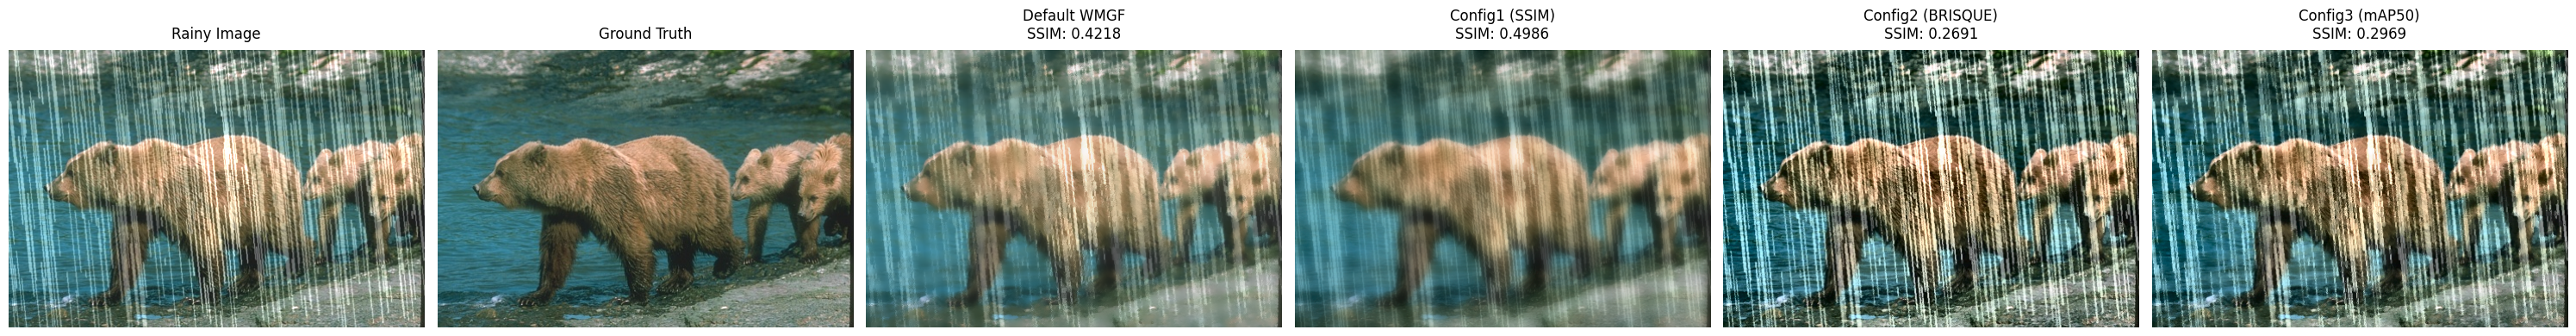


--- Visualization: norain-10.png ---


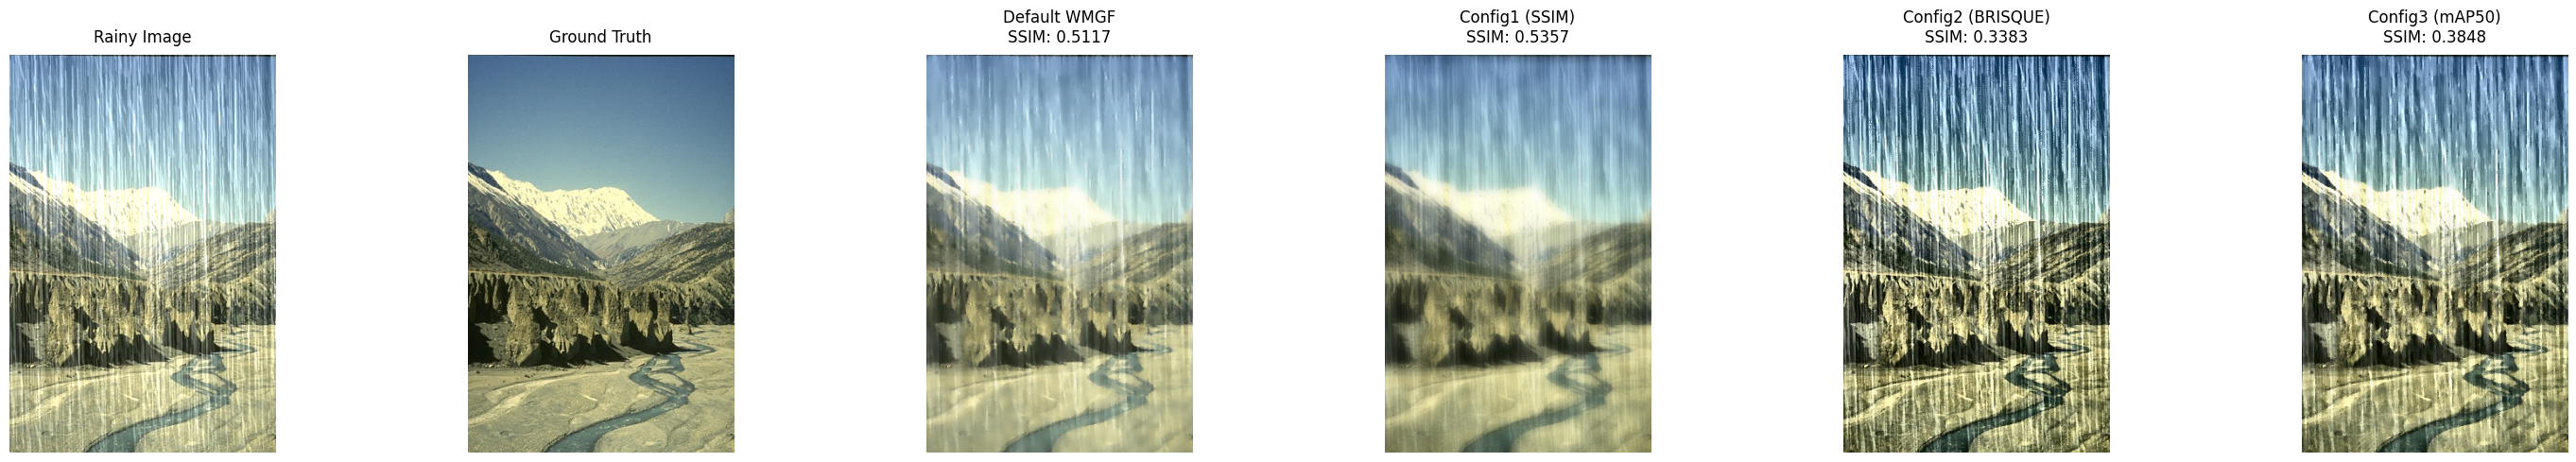


--- Visualization: norain-100.png ---


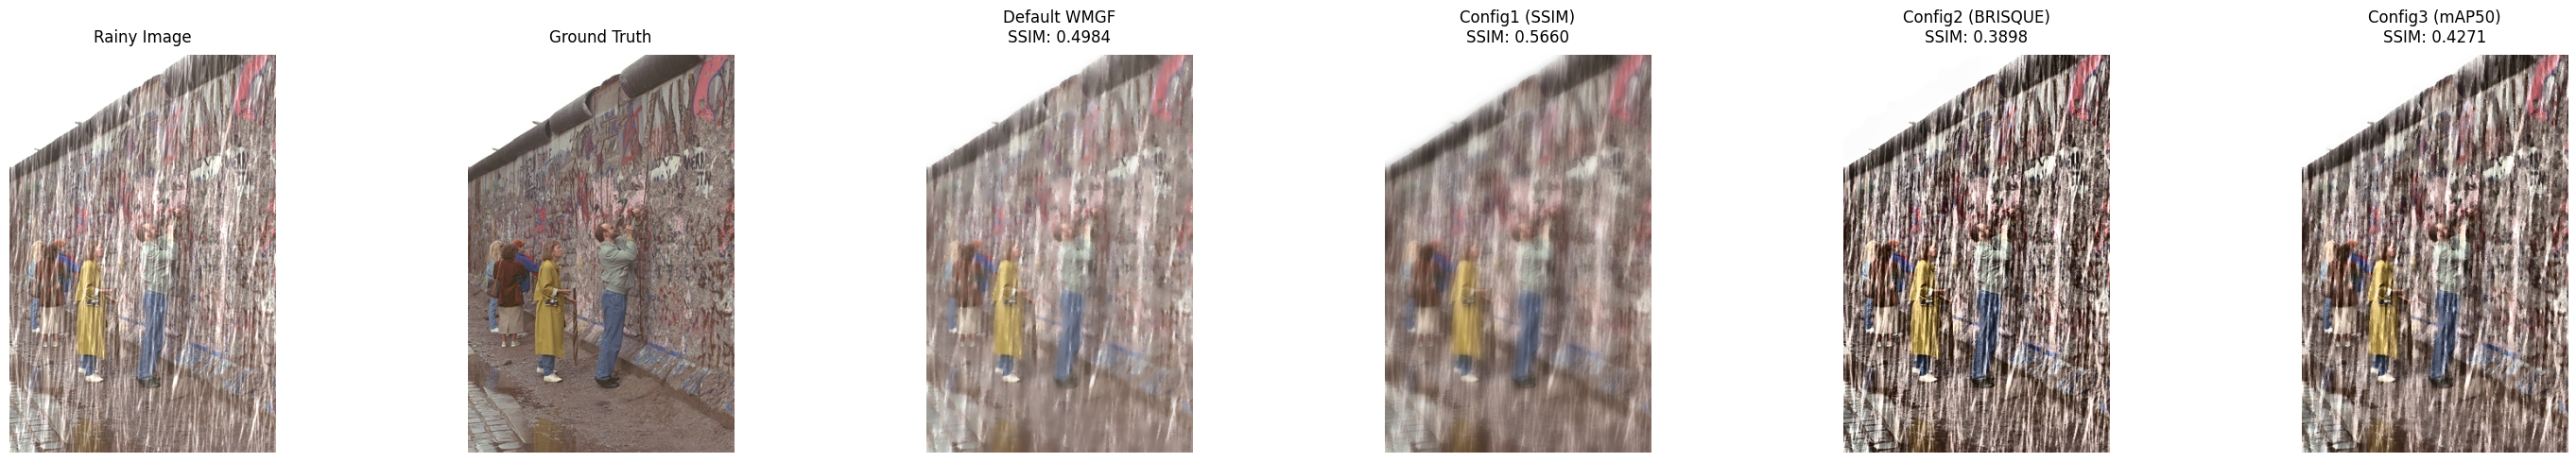

In [5]:
rain100h_test_dir = 'A:/HUST_on_GitHub/ProjectCV/dataset/Rain100H/test/rain'
rain100h_gt_dir = 'A:/HUST_on_GitHub/ProjectCV/dataset/Rain100H/test/norain'

if os.path.exists(rain100h_test_dir):
    test_imgs = sorted(os.listdir(rain100h_test_dir))[:3]
    for img_name in test_imgs:
        print("\n==================================================")
        print(f"--- Visualization: {img_name} ---")
        img_path = os.path.join(rain100h_test_dir, img_name)
        # The GT images in norain directory might have different names, e.g. norain-001.png instead of rain-001.png
        gt_path = os.path.join(rain100h_gt_dir, img_name.replace('rain', 'norain'))
        if not os.path.exists(gt_path):
             gt_path = os.path.join(rain100h_gt_dir, img_name) # Fallback if names are identical
        
        orig_img = cv2.imread(img_path)
        gt_img = cv2.imread(gt_path) if os.path.exists(gt_path) else None
        
        images = [orig_img]
        titles = ['Rainy Image']
        if gt_img is not None:
             images.append(gt_img)
             titles.append('Ground Truth')
        
        for cfg_name in ['Default WMGF', 'Config1 (SSIM)', 'Config2 (BRISQUE)', 'Config3 (mAP50)']:
            if cfg_name in filters:
                res_img = filters[cfg_name].restore(orig_img)
                ssim_val = compute_ssim(res_img, gt_img) if gt_img is not None else 0.0
                images.append(res_img)
                titles.append(f'{cfg_name}\nSSIM: {ssim_val:.4f}')
            
        show_images_yolo(images, titles)


## 4. Trực quan hóa kết quả YOLO (DAWN Rain)
So sánh Baseline YOLO (ảnh gốc) vs WMGF Default vs Config 1, 2, 3


--- Visualization: rain_storm-001.jpg ---


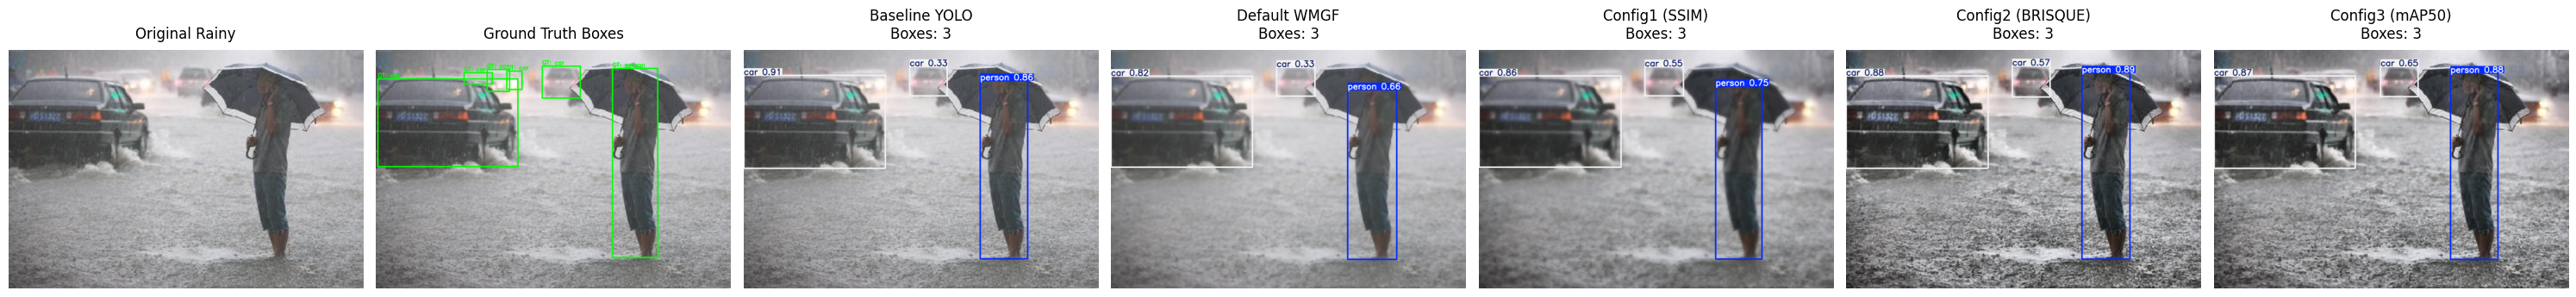


--- Visualization: rain_storm-002.jpg ---


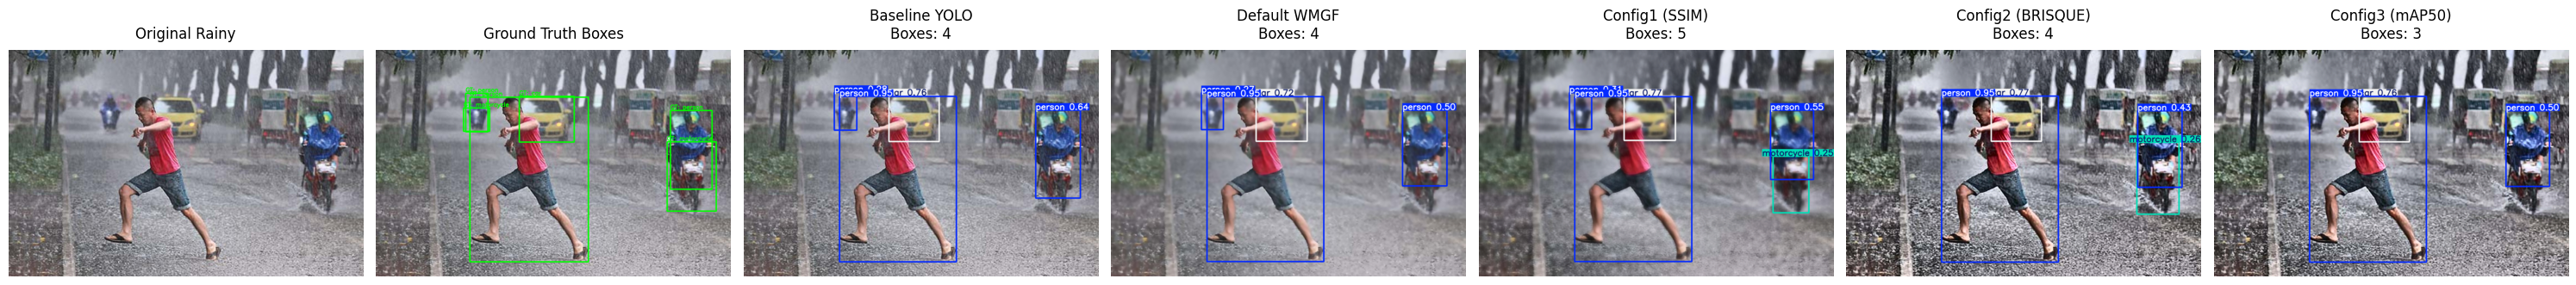


--- Visualization: rain_storm-003.jpg ---


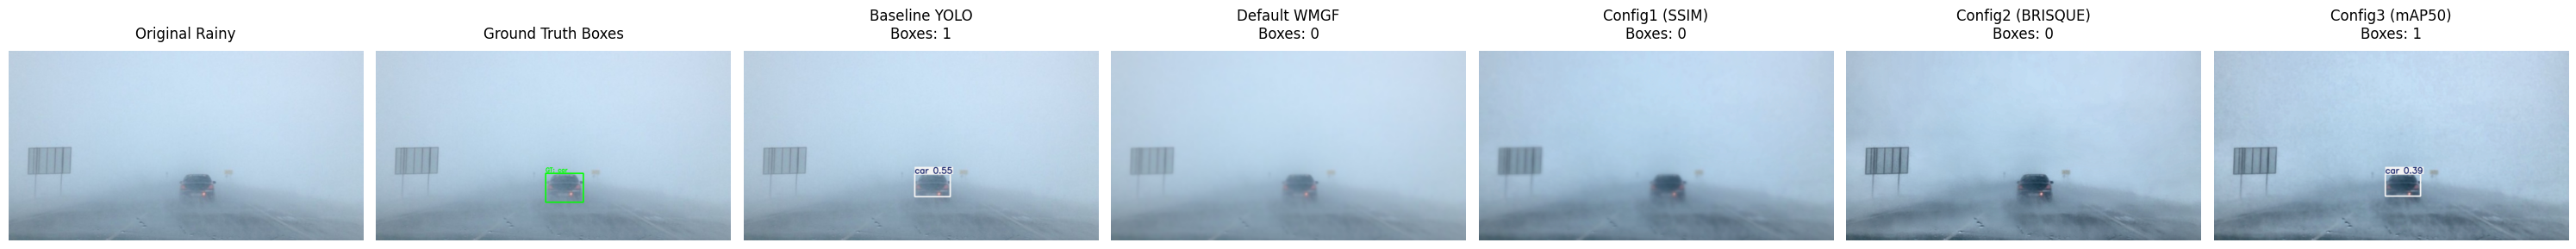

In [6]:
dawn_test_dir = 'A:/HUST_on_GitHub/ProjectCV/data/dawn_rain/images'
dawn_label_dir = 'A:/HUST_on_GitHub/ProjectCV/data/dawn_rain/labels'

if os.path.exists(dawn_test_dir):
    test_imgs = sorted(os.listdir(dawn_test_dir))[:3]
    for img_name in test_imgs:
        print("\n==================================================")
        print(f"--- Visualization: {img_name} ---")
        img_path = os.path.join(dawn_test_dir, img_name)
        label_path = os.path.join(dawn_label_dir, img_name.replace('.jpg', '.txt').replace('.png', '.txt'))
        
        orig_img = cv2.imread(img_path)
        
        gt_img = draw_gt_boxes(orig_img, label_path)
        images = [orig_img, gt_img]
        titles = ['Original Rainy', 'Ground Truth Boxes']
        
        # CHỈ ĐỊNH CLASSES: 0=person, 1=bicycle, 2=car, 3=motorcycle, 5=bus, 7=truck
        allowed_classes = [0, 1, 2, 3, 5, 7]
        
        # Baseline YOLO (No Filter)
        res_baseline = yolo_model(orig_img, classes=allowed_classes, verbose=False)[0]
        images.append(res_baseline.plot())
        titles.append(f'Baseline YOLO\nBoxes: {len(res_baseline.boxes)}')
        
        for cfg_name in ['Default WMGF', 'Config1 (SSIM)', 'Config2 (BRISQUE)', 'Config3 (mAP50)']:
            if cfg_name in filters:
                res_img = filters[cfg_name].restore(orig_img)
                res = yolo_model(res_img, classes=allowed_classes, verbose=False)[0]
                res_plot = res.plot()
                images.append(res_plot)
                titles.append(f'{cfg_name}\nBoxes: {len(res.boxes)}')
            
        show_images_yolo(images, titles)
